In [1]:
## ALL CCM CODE FOR REPLICATION OF ORIGINAL PAPER

In [2]:
## Imports & installs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree
from scipy.stats import pearsonr
import pyreadr
from scipy.optimize import curve_fit
import warnings
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import MultipleLocator
import gzip, struct
import matplotlib.ticker as ticker
from scipy.spatial.distance import cdist
from scipy.linalg import eigh
from scipy.optimize import curve_fit, OptimizeWarning

# pip install pyreadr
# pip install git+https://github.com/williamgilpin/shrec

# Data collection
try:
    result = pyreadr.read_r('sardine_anchovy_sst.RData')
    df_eco = result[list(result.keys())[0]] 
    
    # Preprocess: Align temporal indices and interpolate missing values
    df_eco['year'] = pd.to_datetime(df_eco['year'], format='%Y')
    df_eco = df_eco.sort_values('year').set_index('year')
    df_eco = df_eco.interpolate(method='linear') 
    
    # Standardize units (Z-score normalization helps with distance metrics)
    df_eco_normalized = (df_eco - df_eco.mean()) / df_eco.std()
    
    # Extract specific arrays for later use
    years = df_eco.index.year.values
    sardine = df_eco_normalized['sardine'].values
    anchovy = df_eco_normalized['anchovy'].values
    sst_scripps = df_eco_normalized['sio_sst'].values
    sst_newport = df_eco_normalized['np_sst'].values
    
    print("Data loaded and preprocessed successfully.")
except FileNotFoundError:
    print("Please ensure 'sardine_anchovy_sst.RData' is in your working directory.")

Data loaded and preprocessed successfully.


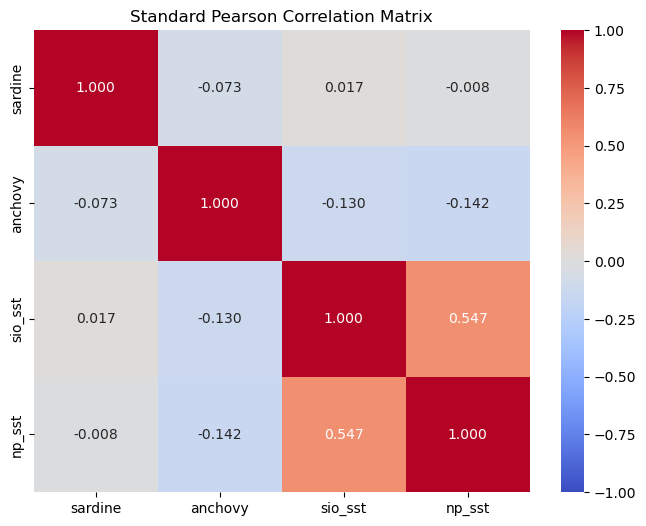

Standard Sardine & Anchovy Pearson r: -0.073


In [4]:
# Correlation matrix

corr_matrix = df_eco_normalized[['sardine', 'anchovy', 'sio_sst', 'np_sst']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f")
plt.title("Standard Pearson Correlation Matrix")
plt.show()

print(f"Standard Sardine & Anchovy Pearson r: {pearsonr(sardine, anchovy)[0]:.3f}")

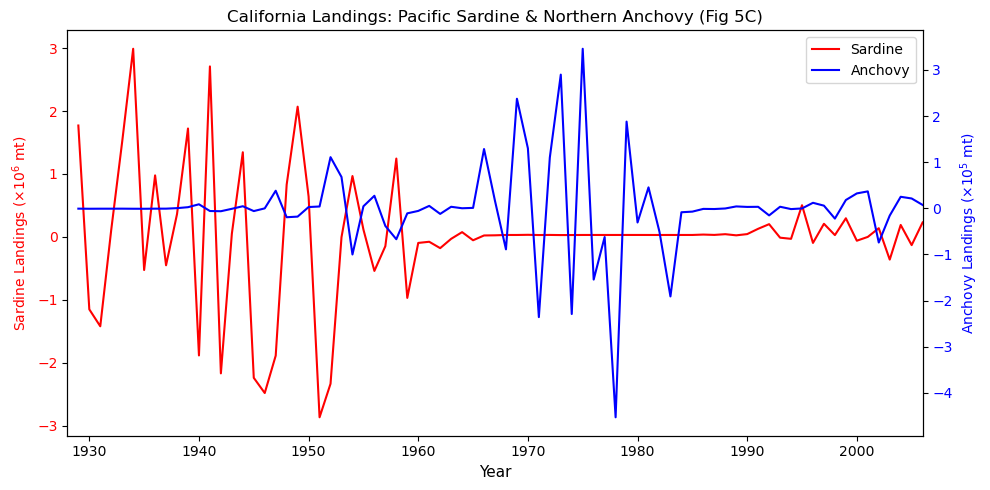

In [5]:
# Sardine-anchovy landings time graph

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel(r'Sardine Landings ($\times 10^6$ mt)', fontsize=10, color='red')
line1, = ax1.plot(years, df_eco['sardine'].values, color='red', linewidth=1.5, label='Sardine')
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_xlim(1928, 2006)

ax2 = ax1.twinx()
ax2.set_ylabel(r'Anchovy Landings ($\times 10^5$ mt)', fontsize=10, color='blue')
line2, = ax2.plot(years, df_eco['anchovy'].values, color='blue', linewidth=1.5, label='Anchovy')
ax2.tick_params(axis='y', labelcolor='blue')

ax1.legend([line1, line2], ['Sardine', 'Anchovy'], loc='upper right', frameon=True)
plt.title('California Landings: Pacific Sardine & Northern Anchovy (Fig 5C)')
fig.tight_layout()
plt.show()

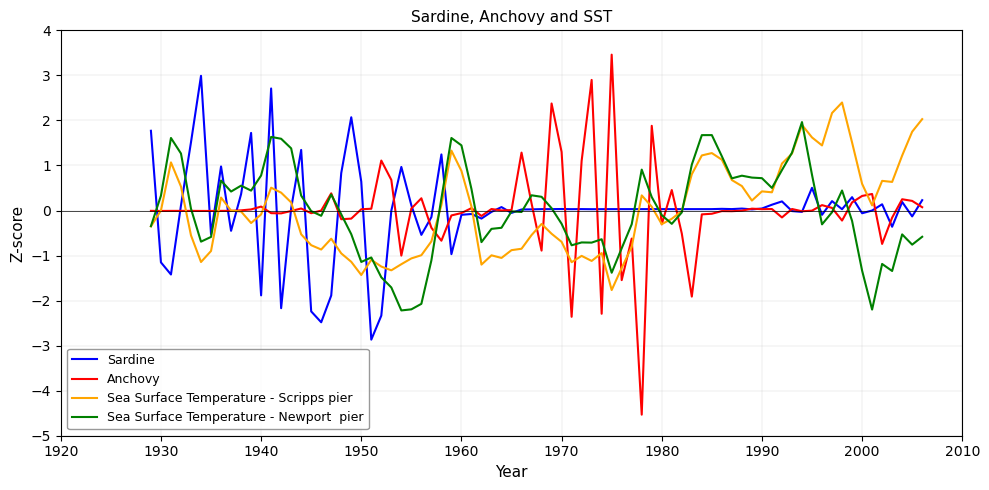

In [6]:
# Time graph with sea surface temperatures

years   = df_eco.index.year.values
sardine = df_eco['sardine'].values
anchovy = df_eco['anchovy'].values
sst_s   = df_eco['sio_sst'].values 
sst_n = df_eco['np_sst'].values

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(years, sardine, color='blue',   linewidth=1.5, label='Sardine')
ax.plot(years, anchovy, color='red',    linewidth=1.5, label='Anchovy')
ax.plot(years, sst_s,     color='orange', linewidth=1.5, label='Sea Surface Temperature - Scripps pier')
ax.plot(years, sst_n,     color='g', linewidth=1.5, label='Sea Surface Temperature - Newport  pier')

ax.axhline(0, color='black', linewidth=0.5, linestyle='-')  # horizontal line at 0
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Z-score', fontsize=11)
ax.set_xlim(1920, 2010)
ax.set_ylim(-5, 4)
ax.legend(loc='lower left', frameon=True, facecolor='white', edgecolor='gray', fontsize=9)
ax.grid(True, linewidth=0.3, alpha=0.5)

ax.set_title('Sardine, Anchovy and SST', fontsize=11)
fig.tight_layout()
plt.show()

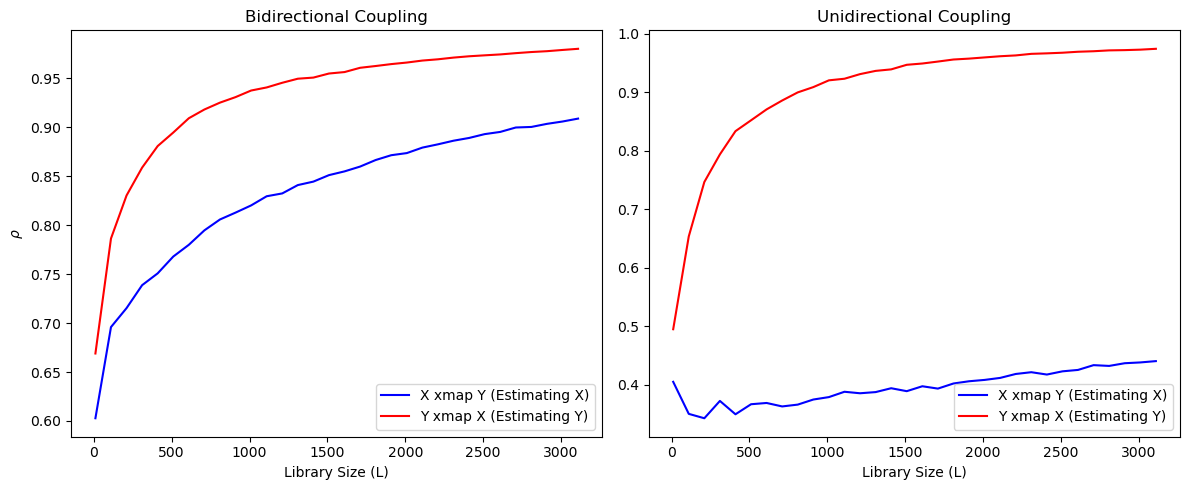

In [20]:
# Convergent cross mapping FIgure 3A

def embed(ts, E, tau=1):
    """Generates time-delay embedding."""
    ts = np.array(ts)
    N = len(ts)
    embedded = np.full((N, E), np.nan)
    for i in range(E):
        shift = i * tau
        if shift == 0:
            embedded[:, i] = ts
        else:
            embedded[shift:, i] = ts[:-shift]
    return embedded
    
def ccm_smooth(X_raw, Y_raw, E, tau=1, L_range=None, num_samples=50):
    """
    Optimized CCM using cKDTree for fast nearest-neighbor lookups.
    """
    np.random.seed(42) 
    X_raw, Y_raw = np.array(X_raw), np.array(Y_raw)
    
    # 1. Embed the state space
    X_embedded = embed(X_raw, E, tau)
    valid_mask = ~np.isnan(X_embedded).any(axis=1) & ~np.isnan(Y_raw)
    valid_indices = np.where(valid_mask)[0]
    
    rho_results = []
    
    for L in L_range:
        rho_L = []
        for _ in range(num_samples):
            # 2. Randomly sample library
            lib_indices = np.random.choice(valid_indices, size=L, replace=False)
            lib_vectors = X_embedded[lib_indices]
            
            # 3. Build a KD-Tree for O(log N) nearest neighbor searches
            tree = cKDTree(lib_vectors)
            
            # 4. Query E+2 neighbors for all valid targets simultaneously
            targets = X_embedded[valid_indices]
            dists, inds = tree.query(targets, k=E+2)
            
            y_preds, y_actuals = [], []
            
            for i, t in enumerate(valid_indices):
                # 5. Filter out the target itself (Leave-one-out cross-validation)
                mask = (lib_indices[inds[i]] != t)
                
                # Take the top E+1 valid neighbors
                valid_nns_idx = inds[i][mask][:E+1]
                valid_dists = dists[i][mask][:E+1]
                
                if len(valid_nns_idx) < E + 1:
                    continue
                    
                # 6. Calculate exponential weights
                d1 = valid_dists[0]
                if d1 == 0:
                    weights = (valid_dists == 0).astype(float)
                else:
                    weights = np.exp(-valid_dists / d1)
                weights /= np.sum(weights)
                
                # 7. Map back to original indices to fetch Y targets
                nn_actual_indices = lib_indices[valid_nns_idx]
                y_pred = np.sum(weights * Y_raw[nn_actual_indices])
                
                y_preds.append(y_pred)
                y_actuals.append(Y_raw[t])
                
            if len(y_preds) > 1:
                r, _ = pearsonr(y_preds, y_actuals)
                rho_L.append(r)
            else:
                rho_L.append(np.nan)
                
        # 8. Average the iterations and cap negative skill at 0
        mean_rho = np.nanmean(rho_L)
        rho_results.append(mean_rho)
        
    rho_results = np.maximum(0, rho_results)
    return np.array(L_range), rho_results
def coupled_logistic(x1, y1, rx, ry, bxy, byx, N):
    X = np.zeros(N)
    Y = np.zeros(N)
    X[0], Y[0] = x1, y1
    for t in range(1, N):
        X[t] = X[t-1] * (rx - rx*X[t-1] - bxy*Y[t-1])
        Y[t] = Y[t-1] * (ry - ry*Y[t-1] - byx*X[t-1])
    return X, Y

N_data = 3500
rx, ry = 3.65, 3.77
L_range_sim = np.arange(10, 3200, 100)

# 1. Bidirectional Coupling 
bxy_bi, byx_bi = 0.02, 0.1
X_bi, Y_bi = coupled_logistic(0.2, 0.4, rx, ry, bxy_bi, byx_bi, N_data)
_, rho_X_bi = ccm_smooth(X_bi, Y_bi, E=2, tau=1, L_range=L_range_sim, num_samples=10)
_, rho_Y_bi = ccm_smooth(Y_bi, X_bi, E=2, tau=1, L_range=L_range_sim, num_samples=10)

# 2. Unidirectional Coupling (Y has no effect on X)
bxy_uni, byx_uni = 0.0, 0.1
X_uni, Y_uni = coupled_logistic(0.2, 0.4, rx, ry, bxy_uni, byx_uni, N_data)
_, rho_X_uni = ccm_smooth(X_uni, Y_uni, E=2, tau=1, L_range=L_range_sim, num_samples=10)
_, rho_Y_uni = ccm_smooth(Y_uni, X_uni, E=2, tau=1, L_range=L_range_sim, num_samples=10)

# Plotting Fig 3A & 3B Equivalent
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(L_range_sim, rho_X_bi, 'b-', label='X xmap Y (Estimating X)')
axes[0].plot(L_range_sim, rho_Y_bi, 'r-', label='Y xmap X (Estimating Y)')
axes[0].set_title('Bidirectional Coupling')
axes[0].set_xlabel('Library Size (L)')
axes[0].set_ylabel(r'$\rho$')
axes[0].legend()

axes[1].plot(L_range_sim, rho_X_uni, 'b-', label='X xmap Y (Estimating X)')
axes[1].plot(L_range_sim, rho_Y_uni, 'r-', label='Y xmap X (Estimating Y)')
axes[1].set_title('Unidirectional Coupling')
axes[1].set_xlabel('Library Size (L)')
axes[1].legend()
plt.tight_layout()
plt.show()
    

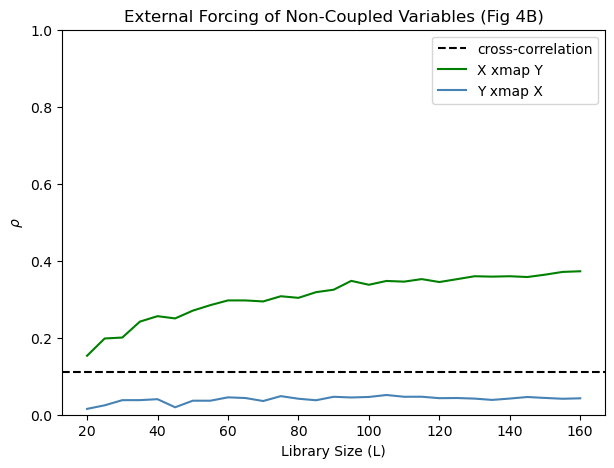

In [8]:
# Figure 4B

np.random.seed(42)
N = 1000
rx, ry, rz = 3.65, 3.77, 3.8
bxz, byz = 0.2, 0.7

Z = np.zeros(N)
X, Y = np.zeros(N), np.zeros(N)
Z[0], X[0], Y[0] = 0.5, 0.2, 0.4

for t in range(1, N):
    Z[t] = Z[t-1] * (rz - rz * Z[t-1])
    X[t] = X[t-1] * (rx - rx * X[t-1] - bxz * Z[t-1])
    Y[t] = Y[t-1] * (ry - ry * Y[t-1] - byz * Z[t-1])

L_range_ext = np.arange(20, 161, 5)
_, rho_XxmapY = ccm_smooth(X, Y, E=2, tau=1, L_range=L_range_ext, num_samples=50)
_, rho_YxmapX = ccm_smooth(Y, X, E=2, tau=1, L_range=L_range_ext, num_samples=50)

cc_value = abs(pearsonr(X, Y)[0])

fig, ax = plt.subplots(figsize=(7, 5))
ax.axhline(cc_value, color='k', linestyle='--', label='cross-correlation')
ax.plot(L_range_ext, rho_XxmapY, color='green', label='X xmap Y')
ax.plot(L_range_ext, rho_YxmapX, color='steelblue', label='Y xmap X')
ax.set_xlabel('Library Size (L)')
ax.set_ylabel(r'$\rho$')
ax.set_ylim(0, 1)
ax.set_title('External Forcing of Non-Coupled Variables (Fig 4B)')
ax.legend()
plt.show()

Running CCM on empirical data (this may take a moment)...


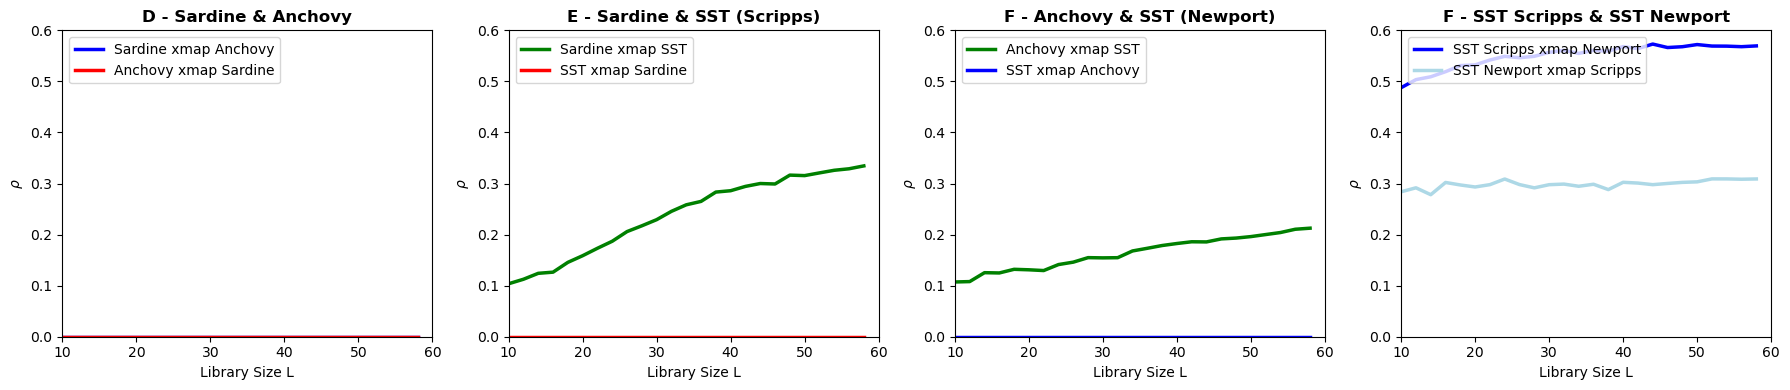


Conclusion:
CCM demonstrates no convergent cross mapping between Sardine and Anchovy.
However, both species show convergence when mapped against their respective SST records, proving they are driven by temperature.


In [9]:
# Figure 5E, 5D, 5F

E_eco = 3
tau_eco = 1
L_range_eco = np.arange(10, 60, 2)

print("Running CCM on empirical data (this may take a moment)...")

# Fig 5D: Sardine vs Anchovy 
_, rho_sard_xmap_anch = ccm_smooth(sardine, anchovy, E_eco, tau_eco, L_range_eco, num_samples=500)
_, rho_anch_xmap_sard = ccm_smooth(anchovy, sardine, E_eco, tau_eco, L_range_eco, num_samples=500)

# Fig 5E: SST (Scripps) vs Sardine
_, rho_sard_xmap_sst = ccm_smooth(sardine, sst_scripps, E_eco, tau_eco, L_range_eco, num_samples=500)
_, rho_sst_xmap_sard = ccm_smooth(sst_scripps, sardine, E_eco, tau_eco, L_range_eco, num_samples=500)

# Fig 5F: SST (Newport) vs Anchovy
_, rho_anch_xmap_sst = ccm_smooth(anchovy, sst_newport, E_eco, tau_eco, L_range_eco, num_samples=500)
_, rho_sst_xmap_anch = ccm_smooth(sst_newport, anchovy, E_eco, tau_eco, L_range_eco, num_samples=500)

# ADDED FIGURES : SST Scripps vs SST Newtport 
_, rho_ssts_xmap_sstnp = ccm_smooth(sst_scripps, sst_newport, E_eco, tau_eco, L_range_eco, num_samples=500)
_, rho_sstnp_xmap_ssts = ccm_smooth(sst_newport, sst_scripps, E_eco, tau_eco, L_range_eco, num_samples=500)

# Plotting the Synthesis
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Panel D
axes[0].plot(L_range_eco, rho_sard_xmap_anch, 'b', linewidth=2.5, label='Sardine xmap Anchovy')
axes[0].plot(L_range_eco, rho_anch_xmap_sard, 'r', linewidth=2.5, label='Anchovy xmap Sardine')
axes[0].set_title('D - Sardine & Anchovy', fontweight='bold')

# Panel E
axes[1].plot(L_range_eco, rho_sard_xmap_sst, 'g', linewidth=2.5, label='Sardine xmap SST')
axes[1].plot(L_range_eco, rho_sst_xmap_sard, 'r', linewidth=2.5, label='SST xmap Sardine')
axes[1].set_title('E - Sardine & SST (Scripps)', fontweight='bold')

# Panel F
axes[2].plot(L_range_eco, rho_anch_xmap_sst, 'g', linewidth=2.5, label='Anchovy xmap SST')
axes[2].plot(L_range_eco, rho_sst_xmap_anch, 'b', linewidth=2.5, label='SST xmap Anchovy')
axes[2].set_title('F - Anchovy & SST (Newport)', fontweight='bold')

# Added Panel 
axes[3].plot(L_range_eco, rho_ssts_xmap_sstnp, 'blue', linewidth=2.5, label='SST Scripps xmap Newport')
axes[3].plot(L_range_eco, rho_sstnp_xmap_ssts, 'lightblue', linewidth=2.5, label='SST Newport xmap Scripps')
axes[3].set_title('F - SST Scripps & SST Newport', fontweight='bold')

for ax in axes:
    ax.set_xlabel('Library Size L')
    ax.set_ylabel(r'$\rho$')
    ax.set_ylim(0, 0.6)
    ax.set_xlim(10, 60)
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

print("\nConclusion:")
print("CCM demonstrates no convergent cross mapping between Sardine and Anchovy.")
print("However, both species show convergence when mapped against their respective SST records, proving they are driven by temperature.")

In [10]:
# Computation of rho values

# Suppress warnings for flat lines that don't fit an exponential curve well
warnings.filterwarnings('ignore', category=OptimizeWarning)

# 1. Define the mathematical model provided
def convergence_model(L, alpha, gamma, rho_inf):
    """ Exponential convergence model: rho(L) = alpha * e^(-gamma * L) + rho_inf """
    return alpha * np.exp(-gamma * L) + rho_inf

# 2. Helper function to fit the curve and print the results
def fit_and_report(L_range, rho_data, label):
    empirical_max = np.nanmax(rho_data)
    empirical_min = np.nanmin(rho_data)
    
    try:
        # Initial guess: alpha (negative amplitude), gamma (small rate), rho_inf (empirical max)
        p0 = [empirical_min - empirical_max, 0.05, empirical_max]
        
        # Bounds: gamma must be > 0 (decay), rho_inf bounded between 0 and 1
        bounds = ([-np.inf, 0, 0], [np.inf, np.inf, 1.0])
        
        # Perform the non-linear least squares fit
        popt, _ = curve_fit(convergence_model, L_range, rho_data, p0=p0, bounds=bounds, maxfev=5000)
        alpha, gamma, rho_inf = popt
        
        # If the curve is basically flat (gamma very close to 0 or alpha very close to 0)
        if gamma < 1e-4 or abs(alpha) < 1e-4:
            print(f"{label:30} | Fit suggests NO convergence (flat line).")
        else:
            print(f"{label:30} | rho(L) = {alpha:7.3f} * e^(-{gamma:.3f} * L) + {rho_inf:.3f}")
            print(f"{'':30} | Converges to (\u03C1_\u221E): {rho_inf:.3f}\n")
            
    except RuntimeError:
        print(f"{label:30} | Curve fitting failed (Likely no convergence).")

print("--- Asymptotic Convergence Analysis (L -> \u221E) ---\n")

# Apply curve fitting to Panel D: Sardine & Anchovy
print("PANEL D: Sardine & Anchovy")
fit_and_report(L_range_eco, rho_sard_xmap_anch, "Sardine xmap Anchovy")
fit_and_report(L_range_eco, rho_anch_xmap_sard, "Anchovy xmap Sardine")

# Apply curve fitting to Panel E: Sardine & SST
print("PANEL E: Sardine & SST (Scripps)")
fit_and_report(L_range_eco, rho_sard_xmap_sst, "Sardine xmap SST Scripps")
fit_and_report(L_range_eco, rho_sst_xmap_sard, "SST Scripps xmap Sardine")

# Apply curve fitting to Panel F: Anchovy & SST
print("PANEL F: Anchovy & SST (Newport)")
fit_and_report(L_range_eco, rho_anch_xmap_sst, "Anchovy xmap SST Newport")
fit_and_report(L_range_eco, rho_sst_xmap_anch, "SST Newport xmap Anchovy")

# Apply curve fitting to Added Panel: SST Spatial Coupling
print("ADDED PANEL: SST vs SST")
fit_and_report(L_range_eco, rho_ssts_xmap_sstnp, "SST Scripps xmap SST Newport")
fit_and_report(L_range_eco, rho_sstnp_xmap_ssts, "SST Newport xmap SST Scripps")

--- Asymptotic Convergence Analysis (L -> ∞) ---

PANEL D: Sardine & Anchovy
Sardine xmap Anchovy           | Fit suggests NO convergence (flat line).
Anchovy xmap Sardine           | Fit suggests NO convergence (flat line).
PANEL E: Sardine & SST (Scripps)
Sardine xmap SST Scripps       | rho(L) =  -0.465 * e^(-0.025 * L) + 0.452
                               | Converges to (ρ_∞): 0.452

SST Scripps xmap Sardine       | Fit suggests NO convergence (flat line).
PANEL F: Anchovy & SST (Newport)
Anchovy xmap SST Newport       | rho(L) =  -0.320 * e^(-0.009 * L) + 0.398
                               | Converges to (ρ_∞): 0.398

SST Newport xmap Anchovy       | Fit suggests NO convergence (flat line).
ADDED PANEL: SST vs SST
SST Scripps xmap SST Newport   | rho(L) =  -0.186 * e^(-0.080 * L) + 0.572
                               | Converges to (ρ_∞): 0.572

SST Newport xmap SST Scripps   | rho(L) =  -0.685 * e^(-0.001 * L) + 0.971
                               | Converges to (ρ_∞): 0.97

In [12]:
# Implement time-delay embedding and nearest-neighbor cross mapping

def psembed(tsdata, E, tau):
    """
    Phase space embedding of a time series (equivalent to psembed.m).
    Constructs a shadow manifold using lagged coordinates.
    """
    N = len(tsdata)
    N_vec = N - (E - 1) * tau
    M = np.zeros((N_vec, E))
    for m in range(N_vec):
        for j in range(E):
            M[m, j] = tsdata[m + (E - j - 1) * tau]
    return M

def xmap(X, Y, MX, MY, E, tau, L, sampling='linear'):
    """
    Calculates cross-mapped estimates of Y from MX and vice versa (equivalent to xmap.m).
    """
    n_points = MX.shape[0]
    
    if sampling == 'linear':
        idx = np.arange(L)
    else: # random
        idx = np.random.choice(n_points, L, replace=False)
        
    MX_lib = MX[idx]
    MY_lib = MY[idx]
    
    # Find E+1 nearest neighbors (search k=E+2 because the closest point is itself)
    tree_X = cKDTree(MX_lib)
    dist_X, ind_X = tree_X.query(MX_lib, k=E+2)
    
    tree_Y = cKDTree(MY_lib)
    dist_Y, ind_Y = tree_Y.query(MY_lib, k=E+2)
    
    EPS = 1e-8 # Prevent division by zero
    
    # Calculate exponentially weighted sums for Y_MX (Estimating Y from X's manifold)
    w_X = np.exp(-dist_X[:, 1:E+2] / (dist_X[:, 1].reshape(-1, 1) + EPS))
    w_X = w_X / w_X.sum(axis=1, keepdims=True)
    
    # Original Y targets corresponding to the neighbors found in MX
    Y_targets = Y[idx[ind_X[:, 1:E+2]] + (E - 1) * tau]
    Y_MX = np.sum(w_X * Y_targets, axis=1)
    
    # Calculate exponentially weighted sums for X_MY (Estimating X from Y's manifold)
    w_Y = np.exp(-dist_Y[:, 1:E+2] / (dist_Y[:, 1].reshape(-1, 1) + EPS))
    w_Y = w_Y / w_Y.sum(axis=1, keepdims=True)
    
    # Original X targets corresponding to the neighbors found in MY
    X_targets = X[idx[ind_Y[:, 1:E+2]] + (E - 1) * tau]
    X_MY = np.sum(w_Y * X_targets, axis=1)
    
    # Actual observations for comparison
    X1 = X[idx + (E - 1) * tau]
    Y1 = Y[idx + (E - 1) * tau]
    
    return X_MY, Y_MX, X1, Y1

def ccm(X, Y, E, tau, L_range, num_iter=10):
    """
    Runs CCM across increasing library sizes L to test for convergence.
    """
    MX = psembed(X, E, tau)
    MY = psembed(Y, E, tau)
    
    rho_X_MY = []
    rho_Y_MX = []
    
    for L in L_range:
        rho_x_runs = []
        rho_y_runs = []
        # Average over random library samplings
        for _ in range(num_iter):
            X_MY, Y_MX, X1, Y1 = xmap(X, Y, MX, MY, E, tau, L, sampling='random')
            r_x, _ = pearsonr(X_MY, X1)
            r_y, _ = pearsonr(Y_MX, Y1)
            rho_x_runs.append(r_x)
            rho_y_runs.append(r_y)
        rho_X_MY.append(np.mean(rho_x_runs))
        rho_Y_MX.append(np.mean(rho_y_runs))
        
    return np.array(rho_X_MY), np.array(rho_Y_MX)

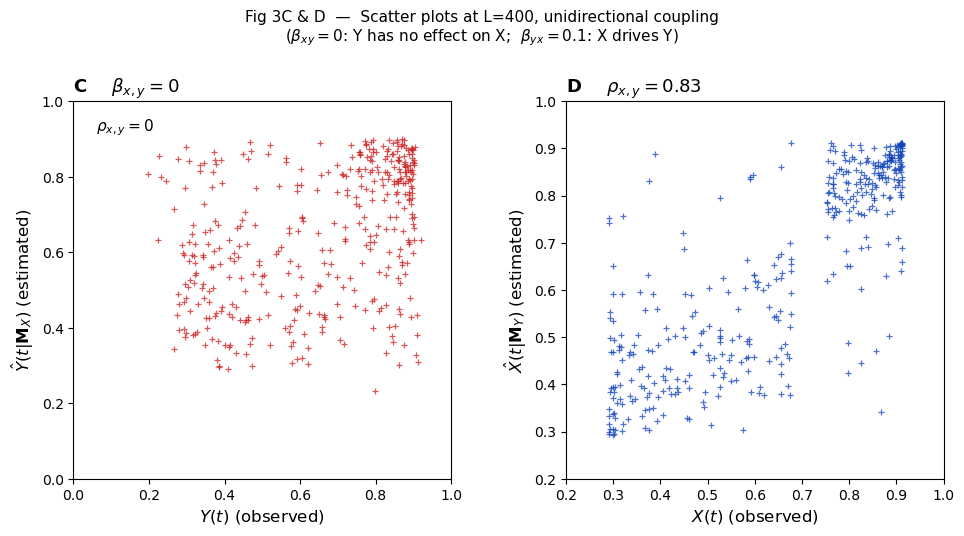

Panel C  rho = 0.389  (Y from M_X) — diffuse cloud, cross-mapping FAILS
Panel D  rho = 0.825  (X from M_Y) — tight diagonal, cross-mapping SUCCEEDS

Why: X causes Y => Y encodes X history (Takens) => M_Y recovers X (D).
     X has NO info about Y (beta_xy=0) => M_X cannot recover Y (C).


In [14]:
# Figure 3C & 3D Scatter plots 
# Uses coupled_logistic, psembed, pearsonr already defined above.

def xmap_scatter_full(X, Y, MX, MY, E, tau):
    """
    Cross-map at fixed L = len(MX)  (full library, self excluded from search).

    Returns
    -------
    Y_hat_MX : Y estimated from M_X  -> Panel C, should FAIL when beta_xy=0
    Y_actual : corresponding observed Y values
    X_hat_MY : X estimated from M_Y  -> Panel D, should SUCCEED when beta_yx>0
    X_actual : corresponding observed X values
    """
    from scipy.spatial import cKDTree
    n   = MX.shape[0]
    EPS = 1e-8

    # Panel C: estimate Y from M_X
    tree_X = cKDTree(MX)
    dist_X, ind_X = tree_X.query(MX, k=E+2)   # k=E+2: index 0 is self, skip it
    w_X  = np.exp(-dist_X[:, 1:E+2] / (dist_X[:, 1].reshape(-1, 1) + EPS))
    w_X /= w_X.sum(axis=1, keepdims=True)
    Y_actual = np.array([Y[m + (E-1)*tau] for m in range(n)])
    Y_nbr    = np.array([[Y[ind_X[m, k+1] + (E-1)*tau] for k in range(E+1)] for m in range(n)])
    Y_hat_MX = np.sum(w_X * Y_nbr, axis=1)

    # Panel D: estimate X from M_Y
    tree_Y = cKDTree(MY)
    dist_Y, ind_Y = tree_Y.query(MY, k=E+2)
    w_Y  = np.exp(-dist_Y[:, 1:E+2] / (dist_Y[:, 1].reshape(-1, 1) + EPS))
    w_Y /= w_Y.sum(axis=1, keepdims=True)
    X_actual = np.array([X[m + (E-1)*tau] for m in range(n)])
    X_nbr    = np.array([[X[ind_Y[m, k+1] + (E-1)*tau] for k in range(E+1)] for m in range(n)])
    X_hat_MY = np.sum(w_Y * X_nbr, axis=1)

    return Y_hat_MX, Y_actual, X_hat_MY, X_actual


# Generate L=400 points of the unidirectional system (beta_xy=0, beta_yx=0.1)
np.random.seed(42)
N_scatter       = 400      # full series length = library size L
rx_s, ry_s      = 3.65, 3.77
E_s, tau_s      = 2, 1
bxy_s, byx_s    = 0.0, 0.1

X_s, Y_s = coupled_logistic(0.2, 0.4, rx_s, ry_s, bxy_s, byx_s, N_scatter)
MX_s     = psembed(X_s, E_s, tau_s)
MY_s     = psembed(Y_s, E_s, tau_s)

Y_hat_MX, Y_obs_s, X_hat_MY, X_obs_s = xmap_scatter_full(
    X_s, Y_s, MX_s, MY_s, E_s, tau_s
)

rho_C, _ = pearsonr(Y_hat_MX, Y_obs_s)
rho_D, _ = pearsonr(X_hat_MY, X_obs_s)

# ── Plotting ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Panel C — diffuse red cloud: cross-mapping FAILS
axes[0].scatter(Y_obs_s, Y_hat_MX,
                color='#CC2222', alpha=0.75, s=22,
                marker='+', linewidths=0.9)
axes[0].set_xlabel('$Y(t)$ (observed)', fontsize=12)
axes[0].set_ylabel(r'$\hat{Y}(t|\mathbf{M}_X)$ (estimated)', fontsize=12)
axes[0].set_title(r'C    $\beta_{x,y} = 0$', fontsize=13, loc='left', fontweight='bold')
axes[0].annotate(r'$\rho_{x,y} = 0$', xy=(0.06, 0.92),
                 xycoords='axes fraction', fontsize=11)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_aspect('equal')

# Panel D — blue diagonal: cross-mapping SUCCEEDS
axes[1].scatter(X_obs_s, X_hat_MY,
                color='#1144BB', alpha=0.75, s=22,
                marker='+', linewidths=0.9)
axes[1].set_xlabel('$X(t)$ (observed)', fontsize=12)
axes[1].set_ylabel(r'$\hat{X}(t|\mathbf{M}_Y)$ (estimated)', fontsize=12)
axes[1].set_title(f'D    $\\rho_{{x,y}} = {rho_D:.2f}$',
                  fontsize=13, loc='left', fontweight='bold')
axes[1].set_xlim(0.2, 1)
axes[1].set_ylim(0.2, 1)
axes[1].set_aspect('equal')

plt.suptitle(
    'Fig 3C & D  —  Scatter plots at L=400, unidirectional coupling\n'
    r'($\beta_{xy}=0$: Y has no effect on X;  $\beta_{yx}=0.1$: X drives Y)',
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.show()

print(f'Panel C  rho = {rho_C:.3f}  (Y from M_X) — diffuse cloud, cross-mapping FAILS')
print(f'Panel D  rho = {rho_D:.3f}  (X from M_Y) — tight diagonal, cross-mapping SUCCEEDS')
print()
print('Why: X causes Y => Y encodes X history (Takens) => M_Y recovers X (D).')
print('     X has NO info about Y (beta_xy=0) => M_X cannot recover Y (C).')

In [16]:
# Defining function (+logistic map & EDM helpers)

# ── Coupled logistic map ─────────────────────────────────────────────────────
def coupled_logistic(beta_xy, beta_yx, rx=3.8, ry=3.5, N=2000, warmup=200):
    """Generate X, Y from the coupled logistic map."""
    X = np.zeros(N + warmup); Y = np.zeros(N + warmup)
    X[0], Y[0] = 0.4, 0.2
    for t in range(N + warmup - 1):
        X[t+1] = X[t] * (rx - rx*X[t] - beta_xy*Y[t])
        Y[t+1] = Y[t] * (ry - ry*Y[t] - beta_yx*X[t])
    return X[warmup:], Y[warmup:]

# ── EDM helpers ──────────────────────────────────────────────────────────────
def make_embedding(ts, E):
    """Time-delay embedding, returns matrix (T x E)."""
    return np.array([[ts[i - j] for j in range(E)]
                     for i in range(E - 1, len(ts))])

def ccm_rho(X, Y, E=3, L=None, seed=0):
    """
    Cross-map skill: use X manifold to reconstruct Y.
    Returns Pearson rho; np.nan if degenerate.
    """
    M   = make_embedding(X, E)
    Y_t = Y[E - 1 : E - 1 + M.shape[0]]
    T   = M.shape[0]
    if L is None or L >= T:
        L = T - 1
    rng = np.random.default_rng(seed)
    lib = rng.choice(T - 1, size=L, replace=False)

    preds, actuals = [], []
    for t in range(T - 1):
        d = np.sqrt(np.sum((M[lib] - M[t])**2, axis=1))
        d[lib == t] = np.inf
        nn  = np.argsort(d)[: E + 1]
        dw  = d[nn]
        w   = np.exp(-dw / (dw[0] + 1e-12)); w /= w.sum()
        preds.append(np.dot(w, Y_t[lib[nn]]))
        actuals.append(Y_t[t])

    a, p = np.array(actuals), np.array(preds)
    return np.corrcoef(a, p)[0, 1] if np.std(p) > 1e-10 else np.nan

print("Functions defined.")

Functions defined.


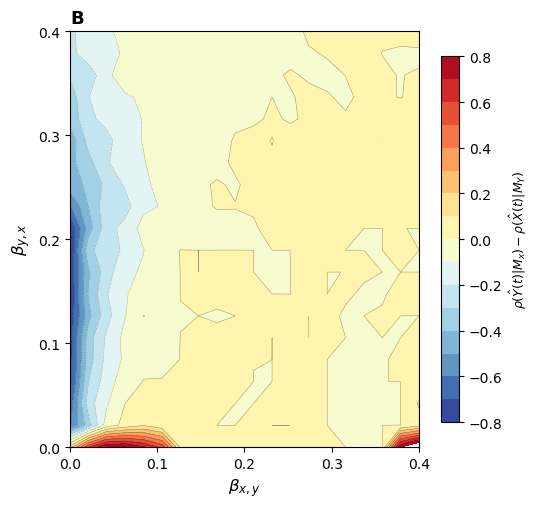

In [17]:
# Figure 3B

betas    = np.linspace(0, 0.4, 20)   # defined here, not separately
rho_diff = np.zeros((len(betas), len(betas)))

for i, b_yx in enumerate(betas):
    for j, b_xy in enumerate(betas):
        X, Y   = coupled_logistic(b_xy, b_yx, N=600, warmup=200)
        rho_x  = ccm_rho(X, Y, E=3, L=400)
        rho_y  = ccm_rho(Y, X, E=3, L=400)
        rho_diff[i, j] = rho_x - rho_y
fig, ax = plt.subplots(figsize=(5.5, 5.2))

B_X, B_Y = np.meshgrid(betas, betas)
lvls = np.linspace(-0.8, 0.8, 17)

cf = ax.contourf(B_X, B_Y, rho_diff, levels=lvls, cmap='RdYlBu_r')
ax.contour(B_X, B_Y, rho_diff, levels=lvls,
           colors='k', linewidths=0.35, alpha=0.4)

cb = plt.colorbar(cf, ax=ax, shrink=0.88)
cb.set_label(r'$\rho(\hat{Y}(t)|M_x) - \rho(\hat{X}(t)|M_Y)$', fontsize=9)
cb.ax.yaxis.set_major_locator(MultipleLocator(0.2))

ax.set_xlabel(r'$\beta_{x,y}$', fontsize=12)
ax.set_ylabel(r'$\beta_{y,x}$', fontsize=12)
ax.set_xlim(0, 0.4); ax.set_ylim(0, 0.4)
ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.set_title('B', fontsize=13, fontweight='bold', loc='left')

plt.tight_layout()
plt.savefig('panel_B.png', dpi=150, bbox_inches='tight')
plt.show()


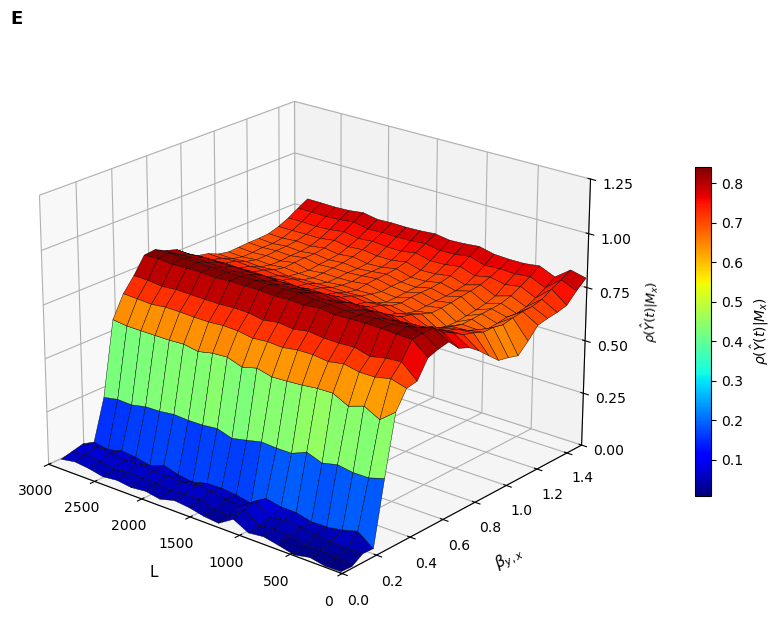

In [18]:
# Figure 3E

beta_xy_fixed = 0.0          # paper explicitly sets this to 0
L_vals        = np.arange(10, 3001, 150)   # up to 3000
beta_yx_vals  = np.linspace(0, 1.5, 25)

rho_E = np.zeros((len(L_vals), len(beta_yx_vals)))

for j, b_yx in enumerate(beta_yx_vals):
    X, Y = coupled_logistic(beta_xy_fixed, b_yx, N=3500, warmup=500)
    for i, L in enumerate(L_vals):
        r = ccm_rho(X, Y, E=3, L=int(L))
        rho_E[i, j] = max(r, 0) if not np.isnan(r) else 0

BV, LV = np.meshgrid(beta_yx_vals, L_vals)

fig  = plt.figure(figsize=(9, 6.5))
ax3d = fig.add_subplot(111, projection='3d')

surf = ax3d.plot_surface(LV, BV, rho_E,
                          cmap='jet', edgecolor='k',
                          linewidth=0.3, antialiased=True)

cbar = fig.colorbar(surf, ax=ax3d, shrink=0.55, pad=0.1)
cbar.set_label(r'$\rho(\hat{Y}(t)|M_x)$', fontsize=10)
cbar.ax.yaxis.set_major_locator(MultipleLocator(0.1))

ax3d.set_xlabel('L', fontsize=11, labelpad=10)
ax3d.set_ylabel(r'$\beta_{y,x}$', fontsize=11, labelpad=10)
ax3d.set_zlabel(r'$\rho(\hat{Y}(t)|M_x)$', fontsize=9, labelpad=6)
ax3d.set_xlim(3000, 0)   # reversed, now goes to 3000
ax3d.set_ylim(0, 1.5)
ax3d.set_zlim(0, 1.25)
ax3d.set_zticks([0, 0.25, 0.5, 0.75, 1.0, 1.25])
ax3d.view_init(elev=22, azim=-50)
ax3d.set_title('E', fontsize=13, fontweight='bold', loc='left')

plt.tight_layout()
plt.savefig('panel_E.png', dpi=150, bbox_inches='tight')
plt.show()


Successfully loaded 78 annual observations (1929–2006)


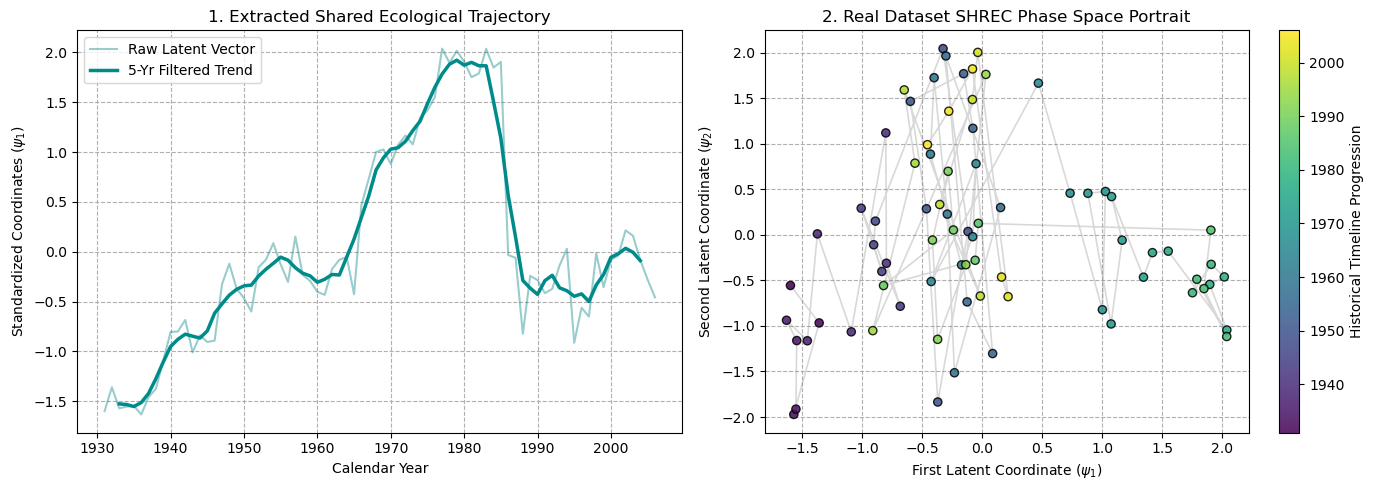

In [19]:
# Shrec Code

# ── STEP 1: LOAD THE ORIGINAL DATASET ────────────────────────────────────────
result = pyreadr.read_r('sardine_anchovy_sst.RData')
df_eco = result[list(result.keys())[0]]

df_eco['year'] = pd.to_datetime(df_eco['year'], format='%Y')
df_eco = df_eco.sort_values('year').set_index('year')
df_eco = df_eco.interpolate(method='linear')

years   = df_eco.index.year.values
anchovy = df_eco['anchovy'].values
sardine = df_eco['sardine'].values
sio_sst = df_eco['sio_sst'].values
np_sst  = df_eco['np_sst'].values

print(f"Successfully loaded {len(years)} annual observations ({int(years[0])}–{int(years[-1])})")


# ── STEP 2: CHOOSE TARGET VARIABLES ──────────────────────────────────────────
# Pick your target pairing here.
ts1 = anchovy
ts2 = sardine


# ── STEP 3: Z-SCORE STANDARDIZATION ──────────────────────────────────────────
ts1_norm = (ts1 - np.mean(ts1)) / np.std(ts1)
ts2_norm = (ts2 - np.mean(ts2)) / np.std(ts2)


# ── STEP 4: LOCALIZED MANIFOLD ENGINE ────────────────────────────────────────
def create_recurrence_matrix(ts, E=3, tau=1, k=10):
    """Creates a localized k-NN affinity matrix optimized for small historical vectors."""
    n = len(ts)
    n_embed = n - (E - 1) * tau
    M = np.array([[ts[i + (E-1)*tau - j*tau] for j in range(E)] for i in range(n_embed)])
    dists = cdist(M, M, metric='euclidean')

    A = np.zeros_like(dists)
    for i in range(n_embed):
        nn_idx = np.argsort(dists[i])[1:k+1]
        sigma = np.mean(dists[i, nn_idx]) + 1e-12
        A[i, nn_idx] = np.exp(-dists[i, nn_idx]**2 / (2 * sigma**2))

    return (A + A.T) / 2


def shrec_reconstruct(ts_list, E=3, tau=1, k=10, n_components=2):
    """SHREC pipeline pulling multiple coordinates for phase-space embedding."""
    A_list = [create_recurrence_matrix(ts, E=E, tau=tau, k=k) for ts in ts_list]
    A_consensus = np.sum(A_list, axis=0)

    degrees = np.sum(A_consensus, axis=1)
    degrees[degrees == 0] = 1e-12
    D_inv_sqrt = np.diag(1.0 / np.sqrt(degrees))

    L = np.eye(len(A_consensus)) - D_inv_sqrt @ A_consensus @ D_inv_sqrt
    eigenvalues, eigenvectors = eigh(L)

    idx = np.argsort(eigenvalues)
    eigenvectors = eigenvectors[:, idx]

    return eigenvectors[:, 1:1+n_components]


# ── STEP 5: ECOPARAMETER RUNTIME CONFIGURATION ───────────────────────────────
E_param = 3
k_param = 10

latent_modes = shrec_reconstruct([ts1_norm, ts2_norm], E=E_param, tau=1, k=k_param, n_components=2)

psi_1 = (latent_modes[:, 0] - np.mean(latent_modes[:, 0])) / np.std(latent_modes[:, 0])
psi_2 = (latent_modes[:, 1] - np.mean(latent_modes[:, 1])) / np.std(latent_modes[:, 1])


# ── STEP 6: GEOMETRIC PLOTTING LAYER ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

time_axis = years[(E_param-1):]
axes[0].plot(time_axis, psi_1, color='teal', alpha=0.4, label='Raw Latent Vector')

window_size = 5
smoothed_psi1 = np.convolve(psi_1, np.ones(window_size)/window_size, mode='same')
half_w = window_size // 2
axes[0].plot(time_axis[half_w:-half_w], smoothed_psi1[half_w:-half_w], color='darkcyan', linewidth=2.5, label='5-Yr Filtered Trend')

axes[0].set_xlabel('Calendar Year')
axes[0].set_ylabel('Standardized Coordinates ($\psi_1$)')
axes[0].set_title('1. Extracted Shared Ecological Trajectory')
axes[0].grid(True, linestyle='--')
axes[0].legend()

scatter = axes[1].scatter(psi_1, psi_2, c=time_axis, cmap='viridis', s=35, edgecolor='k', alpha=0.85, zorder=3)
axes[1].plot(psi_1, psi_2, color='gray', alpha=0.3, linewidth=1.2, zorder=2)

axes[1].set_xlabel('First Latent Coordinate ($\psi_1$)')
axes[1].set_ylabel('Second Latent Coordinate ($\psi_2$)')
axes[1].set_title('2. Real Dataset SHREC Phase Space Portrait')
axes[1].grid(True, linestyle='--')

cbar = fig.colorbar(scatter, ax=axes[1])
cbar.set_label('Historical Timeline Progression')

plt.tight_layout()
plt.show()